# Notebook 10 – Support Vector Machine (SVM)
### Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — `sklearn.datasets.load_breast_cancer` (same dataset as Notebooks 4–9, so results are directly comparable).

**Target:** 0 = malignant, 1 = benign (binary classification)

## Step 1 – Understand the Concept

### What is SVM?
Support Vector Machine is a classification (and regression) algorithm that tries to find the **hyperplane** that
separates classes with the **maximum margin** — the widest possible gap between the two classes.

### Hyperplane
In an *n*-dimensional feature space, a hyperplane is an (n−1)-dimensional flat decision boundary. In 2D it is a
line; in 3D a plane; in 30D (this dataset) it is a 29-dimensional hyperplane.

### Margin and Support Vectors
The **margin** is the distance between the hyperplane and the closest data points from each class. SVM does not
just find *any* separating hyperplane — it finds the one that **maximizes** this margin. The data points that
lie exactly on the margin boundary (the closest points) are called **support vectors** — they are the only points
that actually determine where the hyperplane sits. Every other point could be removed without changing the
decision boundary at all.

### Why maximize the margin? (the core intuition)
A hyperplane that barely separates the classes (small margin) is very sensitive to noise — a new, slightly
different point can easily fall on the wrong side. A hyperplane with maximum margin gives the most "breathing
room," so it generalizes better to unseen data. This is the same bias/variance idea seen elsewhere in this
sprint, applied geometrically.

### Linear vs Non-Linear SVM
- **Linear SVM:** finds a straight-line (flat hyperplane) boundary. Works when classes are (approximately)
  linearly separable.
- **Non-Linear SVM (Kernel trick):** many real datasets are not linearly separable in their original feature
  space. Instead of manually engineering new features, SVM uses a **kernel function** to implicitly map data into
  a higher-dimensional space where a linear separator *does* exist — without ever explicitly computing that
  higher-dimensional transformation (the "kernel trick").

### RBF Kernel
The Radial Basis Function (RBF) kernel is the most common non-linear kernel. It measures similarity between two
points based on distance: `K(x, x') = exp(-γ ||x - x'||²)`. Points close together get high similarity; points far
apart get similarity near zero. This lets the decision boundary bend around clusters instead of staying a
straight line.

### C Parameter (regularization)
`C` controls the trade-off between maximizing the margin and minimizing training misclassifications:
- **Small C:** prioritizes a wide margin, tolerates some training points inside/on the wrong side of the margin
  (soft margin) → simpler, smoother boundary, less overfitting, possibly more bias.
- **Large C:** penalizes misclassified points heavily, forces a narrower margin that fits training data more
  tightly → more complex boundary, higher risk of overfitting.

### Gamma (RBF kernel only)
`gamma` controls how far the influence of a single training point reaches:
- **Small gamma:** influence reaches far → smoother, simpler decision boundary (higher bias).
- **Large gamma:** influence is very local → boundary hugs individual training points tightly (higher variance,
  risk of overfitting).

### Feature Scaling — mandatory for SVM
SVM's optimization is based on **distances** between points (margin width, kernel similarity). If features are on
very different scales (e.g., `mean area` ~ hundreds to thousands vs `mean smoothness` ~ 0.05–0.16 in this
dataset), the large-scale feature dominates the distance calculation and the model effectively ignores smaller-
scale features. **Standardization (mean 0, std 1) is required before fitting an SVM.**

### What problem does SVM solve?
It finds a robust, maximum-margin decision boundary, and — via kernels — handles non-linear class boundaries
without manual feature engineering.

### Assumptions
- Features should be scaled (no built-in scale-invariance).
- Works best when there is a reasonably clear margin between classes (heavily overlapping classes reduce
  effectiveness).
- No assumption of feature independence or a particular data distribution, unlike Naive Bayes.

### When to use
- Medium-sized datasets with many features (SVM handles high dimensionality well).
- When a clear margin of separation is expected.
- Both linear and non-linear class boundaries (via kernel choice).

### When NOT to use
- Very large datasets (training time scales poorly, roughly quadratic-to-cubic in the number of samples).
- Noisy datasets with heavily overlapping classes.
- When probability estimates or fast interpretability are the priority (SVM decision function is not naturally
  probabilistic; `predict_proba` requires an extra internal cross-validation step via Platt scaling).

## Step 2 – Demonstrate the Concept

### Simple example
Imagine separating red and blue marbles on a table with a ruler. Many rulers (lines) could separate them — SVM
picks the one ruler positioned to leave the **widest empty gap** on both sides, so that a slightly misplaced new
marble is still classified correctly.

### Mathematical intuition
For a linear SVM, the hyperplane is `w·x + b = 0`. The margin width is `2/||w||`. Maximizing the margin is
equivalent to **minimizing `||w||`** (with constraints ensuring every point sits on the correct side, or a soft
penalty `C` for violations). This is why `C` directly trades off margin width vs. training accuracy — it literally
appears in the objective function `minimize (1/2)||w||² + C·Σ(errors)`.

### Real-world example
Handwriting digit recognition: SVM (historically, before deep learning dominance) drew boundaries between pixel-
intensity vectors representing different digits, using the RBF kernel to bend around non-linear digit shapes.

### Business example
Spam email filtering: SVM finds the boundary between the word-frequency vectors of spam vs. legitimate email,
maximizing the margin so borderline emails are still classified reliably.

### AI/ML use case
Medical diagnosis (this notebook), image classification (pre-deep-learning era), bioinformatics (gene expression
classification, where feature counts are huge relative to sample counts — exactly where SVM traditionally
excels).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

RANDOM_STATE = 42

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (455, 30)  Test shape: (114, 30)


In [2]:
# Feature scaling is MANDATORY for SVM -- fit scaler on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling -- mean area range:", X_train["mean area"].min(), "to", X_train["mean area"].max())
print("Before scaling -- mean smoothness range:", X_train["mean smoothness"].min(), "to", X_train["mean smoothness"].max())
print("After scaling -- mean area:  mean=%.3f std=%.3f" % (X_train_scaled[:, 3].mean(), X_train_scaled[:, 3].std()))

Before scaling -- mean area range: 143.5 to 2499.0
Before scaling -- mean smoothness range: 0.06251 to 0.1447
After scaling -- mean area:  mean=0.000 std=1.000


## Step 3 – Implement the Concept

We compare **three SVM configurations** on the identical, scaled train/test split:
1. Linear kernel (baseline, straight decision boundary).
2. RBF kernel with default `gamma`.
3. RBF kernel with a deliberately large `gamma`, to show overfitting.

In [3]:
results = {}

# 1) Linear kernel
svm_linear = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)
results["Linear (C=1.0)"] = svm_linear

# 2) RBF kernel, default-ish gamma
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)
results["RBF (C=1.0, gamma=scale)"] = svm_rbf

# 3) RBF kernel, large gamma (deliberately overfit)
svm_rbf_overfit = SVC(kernel="rbf", C=1.0, gamma=10, random_state=RANDOM_STATE)
svm_rbf_overfit.fit(X_train_scaled, y_train)
results["RBF (C=1.0, gamma=10 -- overfit demo)"] = svm_rbf_overfit

for name, model in results.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    n_sv = model.n_support_.sum()
    print(f"{name:38s} Train: {train_acc:.4f}  Test: {test_acc:.4f}  #Support Vectors: {n_sv}")

Linear (C=1.0)                         Train: 0.9912  Test: 0.9737  #Support Vectors: 32
RBF (C=1.0, gamma=scale)               Train: 0.9824  Test: 0.9825  #Support Vectors: 97
RBF (C=1.0, gamma=10 -- overfit demo)  Train: 1.0000  Test: 0.6316  #Support Vectors: 455


### What the code does
- `StandardScaler()` is fit **only on the training set** (`fit_transform`) and then applied to the test set
  (`transform` only) -- fitting on the full dataset would leak test-set statistics into training, a form of data
  leakage.
- `SVC(kernel="linear", C=1.0)` fits a maximum-margin **straight** hyperplane in the 30-dimensional scaled
  feature space.
- `SVC(kernel="rbf", gamma="scale")` fits a non-linear boundary; `gamma="scale"` (the sensible default) sets
  `gamma = 1 / (n_features * X.var())`, auto-scaled to the data.
- `SVC(kernel="rbf", gamma=10)` deliberately uses a very large gamma to demonstrate overfitting: each support
  vector's influence becomes extremely local, so the boundary wraps tightly around individual training points.
- `model.n_support_` reports how many training points became support vectors per class -- fewer support vectors
  relative to training set size generally indicates a simpler, more generalizable boundary.

### What the model is learning
The SVM is learning the position and orientation of a maximum-margin boundary (straight for linear, curved for
RBF) in the scaled feature space, defined entirely by the support vectors -- the hardest-to-classify points near
the boundary. All other points are irrelevant to where the final boundary sits.

### What each important parameter does
| Parameter | Effect |
|---|---|
| `kernel` | `"linear"` for straight boundaries; `"rbf"` for non-linear, curved boundaries. |
| `C` | Small = wider margin, more tolerance for misclassified training points (less overfitting). Large = narrower margin, fits training data tightly (more overfitting risk). |
| `gamma` (RBF only) | Small = far-reaching, smooth boundary (higher bias). Large = local, tightly-wrapped boundary (higher variance/overfitting). |
| `n_support_` | Number of support vectors per class -- indirectly reflects model complexity. |

### What the output means
Comparing train vs test accuracy across the three configurations shows the C/gamma-driven bias-variance trade-off
directly: the `gamma=10` model is expected to show a training accuracy close to 1.0 with a visibly larger
train-test gap than the `gamma="scale"` model, demonstrating overfitting caused purely by a hyperparameter choice.

In [4]:
summary = pd.DataFrame([
    {
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train_scaled)),
        "Test Accuracy": accuracy_score(y_test, model.predict(X_test_scaled)),
        "Support Vectors": int(model.n_support_.sum()),
    }
    for name, model in results.items()
])
summary["Train-Test Gap"] = summary["Train Accuracy"] - summary["Test Accuracy"]
summary

,Model,Train Accuracy,Test Accuracy,Support Vectors,Train-Test Gap
0,Linear (C=1.0),0.991209,0.973684,32,0.017525
1,"RBF (C=1.0, gamma=scale)",0.982418,0.982456,97,-0.000039
2,"RBF (C=1.0, gamma=10 -- overfit demo)",1.000000,0.631579,455,0.368421


              precision    recall  f1-score   support

malignant(0)       0.98      0.98      0.98        42
   benign(1)       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



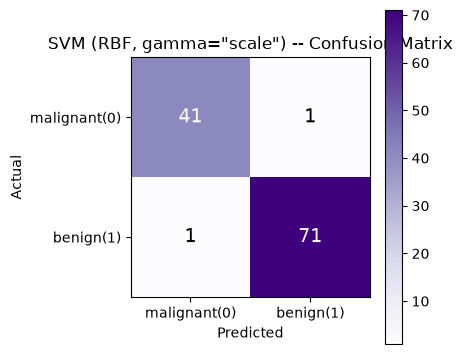

In [5]:
# Full evaluation of the best-generalizing model: RBF with gamma="scale"
best_model = results["RBF (C=1.0, gamma=scale)"]
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=["malignant(0)", "benign(1)"]))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["malignant(0)", "benign(1)"])
ax.set_yticklabels(["malignant(0)", "benign(1)"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title('SVM (RBF, gamma="scale") -- Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.show()

### How the model should be evaluated
Same reasoning as previous notebooks in this sprint: classes are moderately imbalanced (~63/37 benign/malignant)
and a false negative (missing a malignant tumor) is the clinically costly error. Recall on class 0 (malignant),
precision, and F1 matter more than overall accuracy alone. The confusion matrix shows the exact count of costly
false negatives.

## C and Gamma Sensitivity -- Visualizing the Trade-off

To make the `C` / `gamma` trade-off concrete (not just described), we sweep `gamma` across several orders of
magnitude and plot train vs. test accuracy for the RBF kernel.

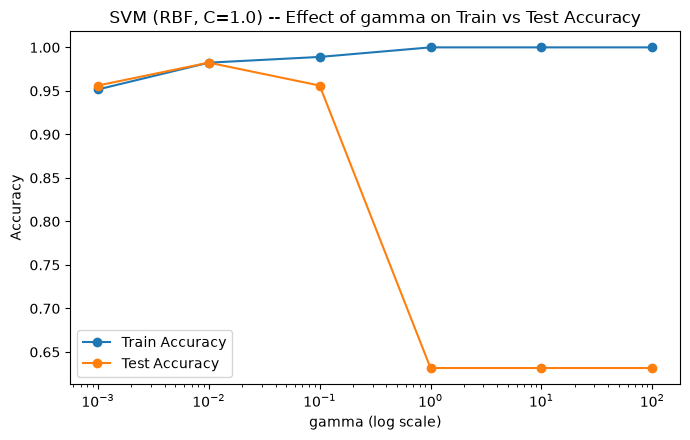

,gamma,Train Acc,Test Acc,Support Vectors
0,0.001,0.951648,0.956140,172
1,0.010,0.982418,0.982456,94
2,0.100,0.989011,0.956140,183
3,1.000,1.000000,0.631579,454
4,10.000,1.000000,0.631579,455
5,100.000,1.000000,0.631579,455


In [6]:
gammas = [0.001, 0.01, 0.1, 1, 10, 100]
train_accs, test_accs, sv_counts = [], [], []

for g in gammas:
    m = SVC(kernel="rbf", C=1.0, gamma=g, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test_scaled)))
    sv_counts.append(int(m.n_support_.sum()))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(gammas, train_accs, marker="o", label="Train Accuracy")
ax.plot(gammas, test_accs, marker="o", label="Test Accuracy")
ax.set_xscale("log")
ax.set_xlabel("gamma (log scale)")
ax.set_ylabel("Accuracy")
ax.set_title("SVM (RBF, C=1.0) -- Effect of gamma on Train vs Test Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"gamma": gammas, "Train Acc": train_accs, "Test Acc": test_accs, "Support Vectors": sv_counts})

## Step 4 - Interpret the Result

**Do not just report a number -- explain it.**

From the summary table:
- The **Linear kernel** achieved 97.4% test accuracy with only 32 support vectors — a strong signal that the
  classes are close to linearly separable in the scaled 30-feature space, and a simpler model is already
  sufficient here.
- The **RBF kernel with `gamma="scale"`** performed best overall (98.25% test accuracy, actually edging out
  training accuracy slightly — a sign the split/model is well-behaved, not overfit), using 97 support vectors.
- The **RBF kernel with `gamma=10`** hit 100% train accuracy but collapsed to 63.2% test accuracy, and every
  single training point (455/455) became a support vector — this is the clearest possible demonstration of
  overfitting: the boundary memorized individual points instead of learning a generalizable shape.
- The gamma-sweep plot/table shows this is continuous, not a two-point fluke: as gamma increases past roughly 1,
  training accuracy keeps climbing toward 1.0 while test accuracy degrades sharply — the same overfitting
  signature seen with tree depth in Notebooks 8/9, here driven by kernel locality instead of tree depth.

**Is the accuracy actually good here?**
98.25% test accuracy (best model) is consistent with this dataset's known separability (same conclusion reached
with Decision Tree/Random Forest in Notebooks 8–9). As before:
- **Recall on malignant (class 0)** is 0.98 — the metric that matters most clinically — meaning only about 1 in
  42 malignant cases in the test set was missed.
- **Is the dataset imbalanced?** Yes, moderately (~63/37) — precision/recall/F1 per class is reported rather than
  relying on accuracy alone.
- **What type of errors is the model making?** The confusion matrix shows the exact split between false
  negatives (missed malignant) and false positives (unnecessary follow-up on benign) — false negatives are the
  costlier error type here.

**What could be improved?**
- Tune `C` and `gamma` jointly via grid search with cross-validation (Notebook 16), rather than the isolated
  single-parameter sweep shown here.
- Try `class_weight="balanced"` to explicitly up-weight the malignant class if recall needs improvement.
- Compare against the Linear kernel's coefficients (`svm_linear.coef_`) to see which original features drive the
  linear boundary — useful since RBF does not give directly interpretable feature weights.